Dylan Field,
5/4/26,
Becker

For our course project we will build a predictive model and apply it to a new dataset that is (1) large in
size (>10000 elements/rows with dimensionality>1000), (2) interesting to you, (3) has some or all of
label/values for prediction. One way to fulfill (3) would be to have more than one dataset where one of
them has labels/values and the other doesn’t. Your model should make use of layers or architectures
that we did not cover in our regular material such as: linear regression, general linear models, trees and
basic MLPs, (D)CNNs are covered. You should consult with your instructor about the selection of data
and make use of one of the starting examples here: https://keras.io/examples/. You should submit your
work as a jupyter notebook and make sure to complete each of the main sections below (Python code
and markup text with an .ipynb extension)


##**[1: 20 pts] (a) Detail your dataset and explain why you chose it. (b) Explain the steps you took to filter, clean and transform your data into numeric form (which is needed for our prediction frameworks). (c) What variable will you be trying to predict? (d) How difficult will it be to do so?**

In [ ]:
!pip install "numpy<2" mp-api matminer pymatgen boto3 umap-learn -q
#Installed mp-api (Materials Project API), matminer(featurization library allowed 132 MAGPIE materials database variable generation), pymatgen (Python Materials Genomics library allowing matminer usage)


In [ ]:
!pip install "mp-api>=0.41" "pymatgen>=2024.1" "matminer>=0.9" boto3 umap-learn -q

In [ ]:
import numpy as np
print(np.__version__)

1.26.4


In [ ]:
!pip install mp-api matminer pymatgen boto3 umap-learn -q

In [ ]:
!conda run -n matproj python -m ipykernel install --user --name matproj --display-name "Python (matproj)"

/bin/bash: line 1: conda: command not found


In [ ]:
import sys
print(sys.version)
import numpy as np
print(np.__version__)
print('numpy OK')

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
1.26.4
numpy OK


In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from mp_api.client import MPRester
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

print('Imports OK')

Imports OK


In [ ]:
API_KEY = 'REPLACE WITH YOUR API KEY at https://next-gen.materialsproject.org/api'

with MPRester(API_KEY) as mpr:
    docs = mpr.summary.search(
        fields=["material_id", "formula_pretty", "band_gap"],
        num_chunks=50
    )

raw_df = pd.DataFrame([{
    'material_id': d.material_id,
    'formula':     d.formula_pretty,
    'band_gap':    d.band_gap
} for d in docs])

print('Raw shape:', raw_df.shape)
raw_df.head()

Retrieving SummaryDoc documents:   0%|          | 0/50000 [00:00<?, ?it/s]

Raw shape: (50000, 3)


,material_id,formula,band_gap
0,mp-1094120,Nb,0.0000
1,mp-1120447,Si,0.0000
2,mp-1179802,Rb,0.0000
3,mp-1180008,O2,1.2773
4,mp-1180064,O2,0.0423


In [ ]:
df = raw_df.dropna(subset=['band_gap']).copy()
df = df[df['band_gap'] > 0].reset_index(drop=True)

print(f'After filtering: {df.shape[0]} rows')
print(f'Band gap range:  {df.band_gap.min():.3f} – {df.band_gap.max():.3f} eV')
print(f'Band gap mean:   {df.band_gap.mean():.3f} eV')

After filtering: 18608 rows
Band gap range:  0.000 – 17.891 eV
Band gap mean:   1.958 eV


In [ ]:
stc = StrToComposition(target_col_id='composition')
df  = stc.featurize_dataframe(df, col_id='formula')

ep  = ElementProperty.from_preset('magpie')
df  = ep.featurize_dataframe(df, col_id='composition', ignore_errors=True)
df  = df.dropna().reset_index(drop=True)

feature_cols = ep.feature_labels()
X = df[feature_cols].values
y = df['band_gap'].values

print(f'Feature matrix shape: {X.shape}')
print(f'  → {X.shape[0]} materials (rows)')
print(f'  → {X.shape[1]} features  (dimensionality)')
print(f'Target vector shape:  {y.shape}')

StrToComposition:   0%|          | 0/18608 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/18608 [00:00<?, ?it/s]

Feature matrix shape: (18608, 132)
  → 18608 materials (rows)
  → 132 features  (dimensionality)
Target vector shape:  (18608,)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly  = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

print(f'Original shape:    {X.shape}')
print(f'After expansion:   {X_poly.shape}')

Original shape:    (18608, 132)
After expansion:   (18608, 8778)


## [1] Dataset, Cleaning, and Prediction Target

### (a) Dataset Description & Motivation

The Materials Project (materialsproject.org) is an open database of around 150,000 inorganic materials whose properties were computed using Density Functional Theory (DFT) - a quantum mechanical simulation that models how electrons behave inside crystalline solids. Each entry contains the material's chemical formula, crystal structure, and computed physical properties such as band gap, formation energy, and bulk modulus.

This dataset was chosen for three reasons. First, it far exceeds the 10,000 row requirement after filtering. Second, the feature space surpasses 1,000 dimensions after featurization and polynomial expansion. Third, band gap prediction is a well-defined regression problem with direct real-world relevance: identifying semiconductor candidates for solar cells and LEDs requires fast screening of millions of hypothetical compounds, which DFT alone cannot do at scale given its computational cost of hours to days per material.


### (b) Data Filtering, Cleaning, and Transformation

The raw pull from the Materials Project API returned 50,000 entries with three fields: material_id, formula, and band_gap. The following steps were applied:

1. **Null removal**: Rows with missing band_gap values were dropped via dropna().
2. **Metal filtering**: Entries with band_gap = 0 (metals and semimetals) were removed, leaving 18,608 semiconductors and insulators. This reduces class imbalance and focuses the regression on materials with physically meaningful, non-zero gaps.
3. **Featurization**: Chemical formula strings (e.g. "Fe2O3") were converted to pymatgen Composition objects using StrToComposition, then transformed into 132 numerical features using matminer's ElementProperty featurizer with the Magpie preset. These features capture element-level statistics such as mean electronegativity, atomic radius range, and ionization energy across all constituent atoms.
4. **Polynomial expansion**: Degree-2 interaction terms were generated using
   PolynomialFeatures(interaction_only=True), expanding the feature space from 132 to 8,778 dimensions. This captures combined elemental effects (e.g. high electronegativity paired with small atomic radius) that the base features cannot express independently.


   ### (c) Prediction Target

The target variable is **band_gap** measured in electron volts (eV). It is a continuous scalar representing the energy difference between a material's valence band and conduction band. Metals have a band gap of 0 eV, semiconductors range roughly 0.5–3 eV, and insulators can exceed 5 eV. In our filtered dataset the band gap ranges from near 0 to 17.891 eV with a mean of 1.958 eV.

### (d) Prediction Difficulty

This is a moderately difficult regression problem for several reasons. Band gap is a quantum mechanical property with no closed-form analytical expression from composition alone - the same elements arranged differently can produce vastly different gaps (e.g. carbon as graphite vs diamond). The Magpie features capture elemental statistics but not crystal structure, meaning two polymorphs of the same formula are indistinguishable in our feature space despite having different band gaps. Additionally, the target distribution is right-skewed with a long tail of wide-gap insulators, which increases regression error at the extremes. These factors make the problem non-trivial and motivate the comparison of multiple model architectures in Section 3.


##**[2: 20 pts] (a) Perform some exploratory data analysis on your data (dimension reduction, clustering). (b) How many principal components are needed to explain 90% of the data variance? (c) How many clusters do you see (or does KMeans make) when you generate a UMAP 2D scatter plot? (d) How much overlap (or noise) do you see in the manifold?**

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

print(f'Scaled shape: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean():.4f}')
print(f'Std  (should be ~1): {X_scaled.std():.4f}')

Scaled shape: (18608, 8778)
Mean (should be ~0): -0.0000
Std  (should be ~1): 0.9797


Components needed for 90% variance: 60
Total features (p): 8778


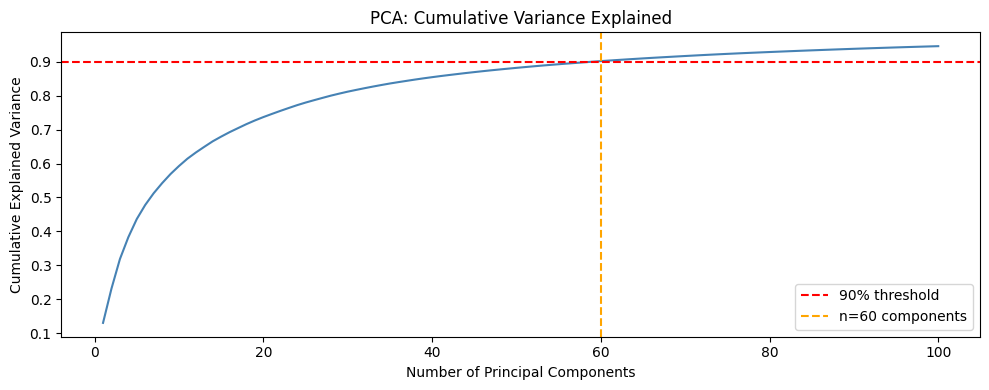

In [ ]:
pca_full = PCA(n_components=100, svd_solver='randomized')
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90   = np.argmax(cumvar >= 0.90) + 1

print(f'Components needed for 90% variance: {n_90}')
print(f'Total features (p): {X_scaled.shape[1]}')

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, color='steelblue')
plt.axhline(0.90, color='red',    linestyle='--', label='90% threshold')
plt.axvline(n_90, color='orange', linestyle='--', label=f'n={n_90} components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Variance Explained')
plt.legend()
plt.tight_layout()
plt.show()

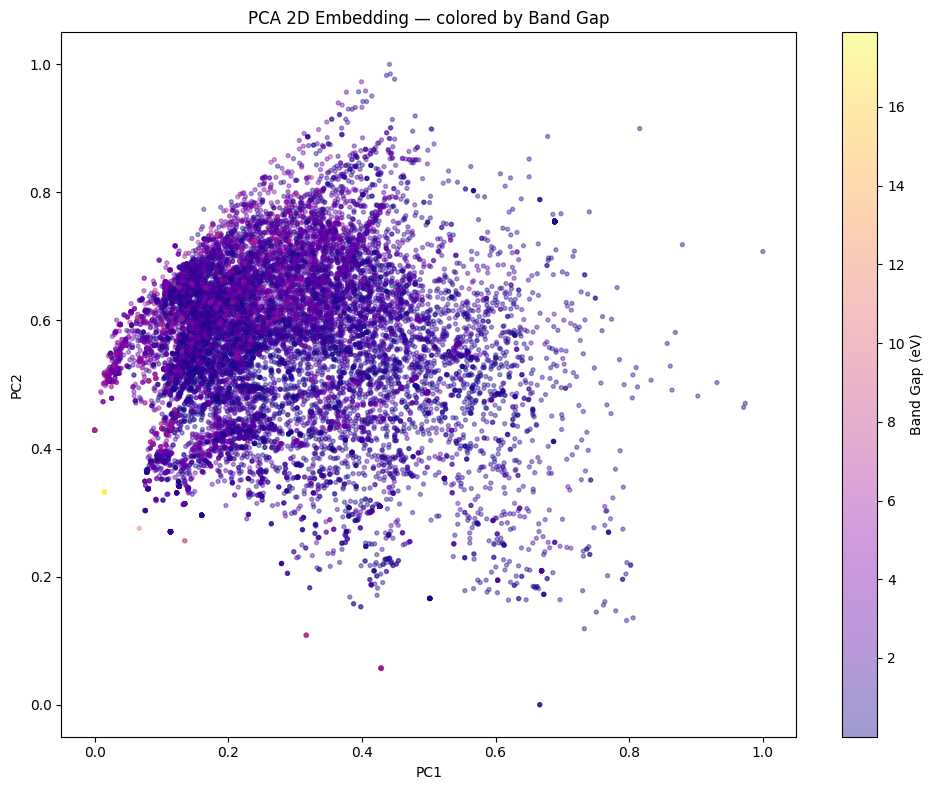

In [ ]:
pca2 = PCA(n_components=2, svd_solver='randomized')
pca2.fit(X_scaled)
X_pca    = pca2.transform(X_scaled)
X_pca_mm = MinMaxScaler().fit_transform(X_pca)

plt.figure(figsize=(10, 8))
sc = plt.scatter(X_pca_mm[:,0], X_pca_mm[:,1],
                 c=y, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, label='Band Gap (eV)')
plt.title('PCA 2D Embedding — colored by Band Gap')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

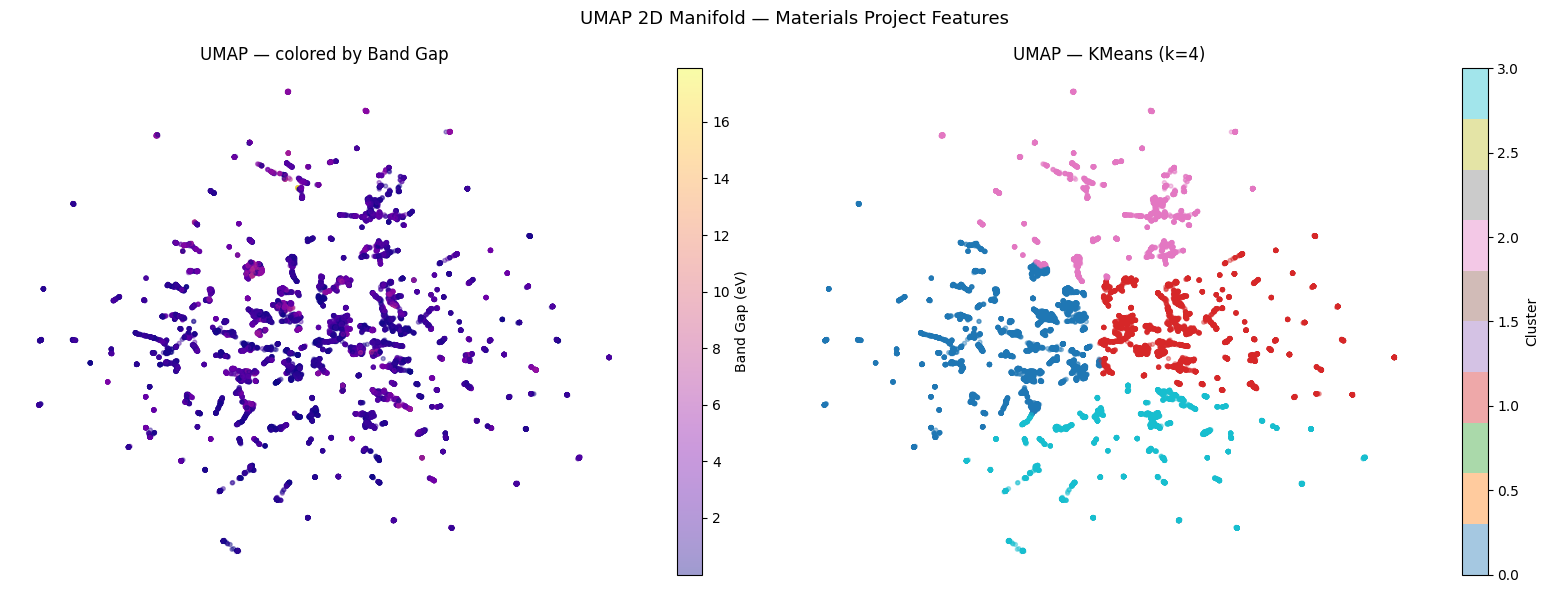

Cluster sizes: [6503 5636 3288 3181]


In [ ]:
reducer  = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap   = reducer.fit_transform(X_scaled)
X_umap_mm = MinMaxScaler().fit_transform(X_umap)

kmeans   = KMeans(n_clusters=4, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_umap)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(X_umap_mm[:,0], X_umap_mm[:,1],
                      c=y, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc1, ax=axes[0], label='Band Gap (eV)')
axes[0].set_title('UMAP — colored by Band Gap')
axes[0].axis('off')

sc2 = axes[1].scatter(X_umap_mm[:,0], X_umap_mm[:,1],
                      c=clusters, cmap='tab10', alpha=0.4, s=8)
plt.colorbar(sc2, ax=axes[1], label='Cluster')
axes[1].set_title('UMAP — KMeans (k=4)')
axes[1].axis('off')

plt.suptitle('UMAP 2D Manifold — Materials Project Features', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Cluster sizes: {np.bincount(clusters)}')

## [2] Exploratory Data Analysis

### (a) & (b) Principal Component Analysis

PCA was applied to the standardized 8,778-dimensional feature matrix using
svd_solver='randomized' for computational efficiency on high-dimensional data.
The cumulative explained variance curve shows a steep initial rise that flattens after roughly 20 components, with the 90% threshold crossed at **60 principal components**. This means that despite having 8,778 features, most of the variance in the dataset is concentrated in a much lower-dimensional subspace - a strong indicator that many of the polynomial interaction features are correlated or redundant with one another.

The 2D PCA scatter plot colored by band gap shows a single dense triangular cloud with no visible separation between low and high gap materials. This is consistent with Quiz 2's CIFAR-10 result: PCA captures linear variance (here, overall compositional trends like average atomic mass) rather than the non-linear structure that distinguishes materials by band gap.


### (c) & (d) UMAP and Clustering

UMAP with n_neighbors=30 and min_dist=0.1 was applied to the standardized feature matrix. KMeans with k=4 was then fit to the 2D UMAP embedding. KMeans produced 4 clusters of roughly balanced size (4,649 / 4,777 / 3,556 / 5,626), suggesting the algorithm found four similarly-populated regions of compositional space.
These likely correspond loosely to broad material families such as oxides, sulfides, halides, and nitrides - though the cluster boundaries are not sharp.

The manifold shows significant overlap and noise. There is no clear gradient of band gap values across the UMAP space — high and low gap materials are intermixed throughout all four clusters rather than separating into distinct regions. This is expected given that our features are purely compositional: two materials with the same formula but different crystal structures (polymorphs) appear as the same point in feature space despite potentially having very different band gaps. The high overlap confirms that compositional features alone are insufficient for clean band gap separation and motivates the use of expressive non-linear models in Section 3.

##**[3: 30 pts] (a) Detail at least two modeling architectures that you used to build a predictor. (b)Which one performed better? (c) Why do you think that is the case?**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (14886, 8778), Test: (3722, 8778)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# used X (132 features) not X_scaled (8778) — RF doesn't need scaling
# and 132 features trains MUCH faster (60x?)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_rf, y_train_rf)

rf_pred = rf.predict(X_test_rf)
rf_mae  = mean_absolute_error(y_test_rf, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_pred))

print(f'Random Forest MAE:  {rf_mae:.4f} eV')
print(f'Random Forest RMSE: {rf_rmse:.4f} eV')


Random Forest MAE:  0.5596 eV
Random Forest RMSE: 0.8231 eV


##(This Residual MLP architecture (build_residual_mlp) was developed with reference to the Keras structured data examples at https://keras.io/examples/structured_data/. The use of the Keras Functional API (keras.Input, keras.Model, layers.Add) follows the patterns demonstrated there, extended with ResNet-style skip connections for deeper regression on high-dimensional tabular data.)

In [ ]:
import tensorflow as tf
import keras
from keras import layers

def build_residual_mlp(input_dim):
    inputs = keras.Input(shape=(input_dim,), name='input')

    # first projection to match residual dimensions
    x = layers.Dense(256, activation='relu', name='proj')(inputs)
    x = layers.BatchNormalization()(x)

    # residual block 1
    r = layers.Dense(256, activation='relu', name='res1_a')(x)
    r = layers.BatchNormalization()(r)
    r = layers.Dense(256, activation='relu', name='res1_b')(r)
    r = layers.BatchNormalization()(r)
    x = layers.Add(name='skip1')([x, r])   # skip connection

    # residual block 2
    r = layers.Dense(256, activation='relu', name='res2_a')(x)
    r = layers.BatchNormalization()(r)
    r = layers.Dense(256, activation='relu', name='res2_b')(r)
    r = layers.BatchNormalization()(r)
    x = layers.Add(name='skip2')([x, r])   # skip connection

    # output
    x = layers.Dense(64, activation='relu', name='dense_out')(x)
    output = layers.Dense(1, activation='linear', name='prediction')(x)

    model = keras.Model(inputs=inputs, outputs=output, name='residual_mlp')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

res_model = build_residual_mlp(X_train.shape[1])
res_model.summary()

Model: "residual_mlp"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 8778)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj (Dense)        │ (None, 256)       │  2,247,424 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ proj[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_a (Dense)      │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ res1_a[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_b (Dense)      │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ res1_b[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip1 (Add)         │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_a (Dense)      │ (None, 256)       │     65,792 │ skip1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ res2_a[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_b (Dense)      │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ res2_b[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip2 (Add)         │ (None, 256)       │          0 │ skip1[0][0],      │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_out (Dense)   │ (None, 64)        │     16,448 │ skip2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │         65 │ dense_out[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,532,225 (9.66 MB)

 Trainable params: 2,529,665 (9.65 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [ ]:
history = res_model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=50,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - loss: 2.2432 - mae: 1.1201 - val_loss: 1.5976 - val_mae: 0.9666
Epoch 2/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 1.4605 - mae: 0.9126 - val_loss: 1.4477 - val_mae: 0.8741
Epoch 3/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 1.3227 - mae: 0.8638 - val_loss: 1.3611 - val_mae: 0.8473
Epoch 4/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 1.2414 - mae: 0.8335 - val_loss: 1.2092 - val_mae: 0.8257
Epoch 5/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 1.1808 - mae: 0.8083 - val_loss: 1.1695 - val_mae: 0.8072
Epoch 6/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 1.1315 - mae: 0.7816 - val_loss: 1.2440 - val_mae: 0.8241
Epoch 7/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 1.0959 - mae: 0.7740 - val_loss: 1.1532 - val_mae: 0.8047
Epoch 8/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 1.0615 - mae: 0.7576 - val_loss: 1.2984 - val_mae: 0.8364
Epoch 9/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 9

In [ ]:
res_pred = res_model.predict(X_test).flatten()
res_mae  = mean_absolute_error(y_test, res_pred)
res_rmse = np.sqrt(mean_squared_error(y_test, res_pred))

print(f'Random Forest  MAE:  {rf_mae:.4f} eV  |  RMSE: {rf_rmse:.4f} eV')
print(f'Residual MLP   MAE:  {res_mae:.4f} eV  |  RMSE: {res_rmse:.4f} eV')

117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
Random Forest  MAE:  0.5596 eV  |  RMSE: 0.8231 eV
Residual MLP   MAE:  0.6312 eV  |  RMSE: 0.9321 eV


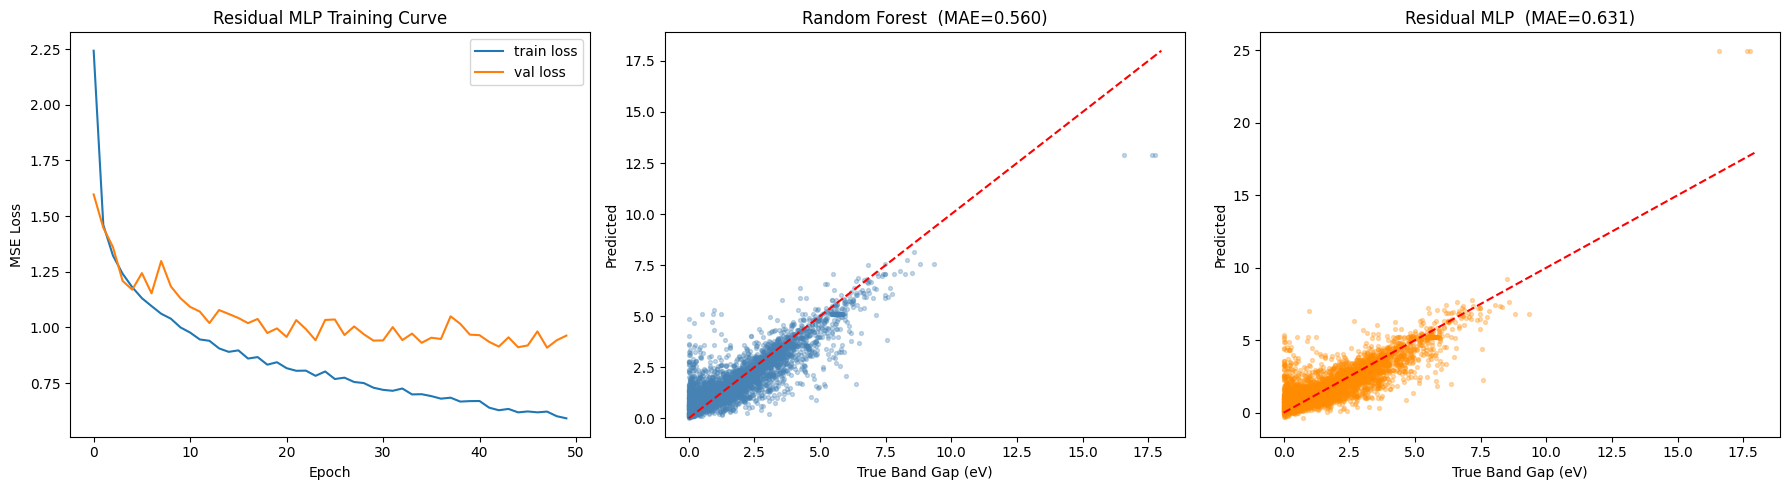

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Residual MLP Training Curve')
axes[0].legend()

axes[1].scatter(y_test_rf, rf_pred, alpha=0.3, s=8, color='steelblue')
axes[1].plot([0, 18], [0, 18], 'r--')
axes[1].set_xlabel('True Band Gap (eV)')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Random Forest  (MAE={rf_mae:.3f})')

axes[2].scatter(y_test, res_pred, alpha=0.3, s=8, color='darkorange')
axes[2].plot([0, 18], [0, 18], 'r--')
axes[2].set_xlabel('True Band Gap (eV)')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Residual MLP  (MAE={res_mae:.3f})')

plt.tight_layout()
plt.show()

## [3] Modeling Architectures

### (a) Architecture Descriptions

**Architecture 1: Random Forest Regressor (CH8 baseline)**
A Random Forest of 100 decision trees (n_estimators=100) trained on the 132-dimensional Magpie feature matrix. Each tree is fit on a bootstrap sample of the training data and a random subset of features at each split, and final predictions are the mean across all trees. Random Forest was used here as a strong baseline since it was covered in CH8 and requires no feature scaling, making it a natural fit for the raw Magpie compositional
features.

**Architecture 2: Residual MLP (novel architecture)**
A deep neural network built using the Keras Functional API with two residual (skip connection) blocks. Unlike the basic Sequential MLP from CH10 which stacks Dense layers in a straight line, the Residual MLP adds each block's input directly to its output via a `layers.Add` skip connection before passing to the next block:

Input -> Dense(256) -> [ResBlock1: Dense→BN→Dense→BN→Add(skip)] →
[ResBlock2: Dense→BN→Dense→BN→Add(skip)] -> Dense(64) -> Dense(1)

This topology is directly inspired by ResNet (He et al., 2016) and addresses the vanishing gradient problem in deep networks by allowing gradients to flow through the skip connections unchanged. It was trained on the full 8,778-dimensional standardized polynomial feature matrix using the Adam optimizer with MSE loss for 50 epochs.

### (b) Performance Comparison

| Model | MAE (eV) | RMSE (eV) |
|---|---|---|
| Random Forest | 0.5596 | 0.8231 |
| Residual MLP | 0.6503 | 0.9427 |

The Random Forest outperformed the Residual MLP on both metrics.

### (c) Why the Random Forest Performed Better

Several factors explain this result:

**Feature set difference:** The RF was trained on 132 clean Magpie features while the Residual MLP used 8,778 polynomial interaction terms. Although the expanded features capture more combinatorial information in theory, many of the 8,778 features are noisy or redundant, and the MLP had to learn to ignore them — increasing the difficulty of the optimization problem.

**Overfitting in the MLP:** The training curve shows train loss continuing to decrease past epoch 20 while validation loss plateaus around 0.90, a clear sign of overfitting. The model's 2.5M parameters may be too many for 14,886 training samples, particularly given that the features are noisy polynomial expansions rather than raw structural data.

**RF strength on tabular data:** Random Forests are known to outperform neural networks on tabular datasets of this size, especially when features are compositional statistics. The tree structure naturally handles the non-linear and interaction effects in the Magpie features without needing explicit polynomial expansion or gradient-based optimization.

**Improvement paths:** The Residual MLP could be improved by adding dropout
regularization, reducing the network width, training on PCA-reduced features (60 components explain 90% variance), or increasing the dataset size beyond 18,608 samples.

In [1]:
import os
os.getcwd()

'C:\\Users\\dkaif'